Dídac Costa Gargallo - u252353

Senyals i Sistemes I

4/11

**Lab 3: Spectral Representation**

The goal of this lab is to gain familiarity with the spectral representations of signals, specially the spectrograms.

In [1]:
import os
import numpy as np
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram, plot_spectrum_at, save_audio
from IPython.display import Audio

First upload your reference signal and plot the first seconds of it.

In [2]:
# Carreguem el senyal de referència 
reference, fs = load_audio('audio/reference.wav')
plot_signals(reference, fs)

# **Exercises**

**1. Spectrograms**

A spectrogram is obtained by estimating the frequency content in short sections of the signal. The magnitude of the spectrum over individual sections is plotted as intensity or color on a two-dimensional plot versus frequency and time. The length of each section, or window length, determines the frequency resolution. Longer windows give good frequency resolution but fail to
track frequency changes well. Shorter windows have poor frequency resolution, but good tracking.

In Python the function `spectrogram` from the `scipy.signal` package will
compute the spectrogram. A common call to the function is defined as follows. No need to understand the meaning of each parameter at this stage. Note that we provide the `plot_spectrogram` function to plot the spectrogram.

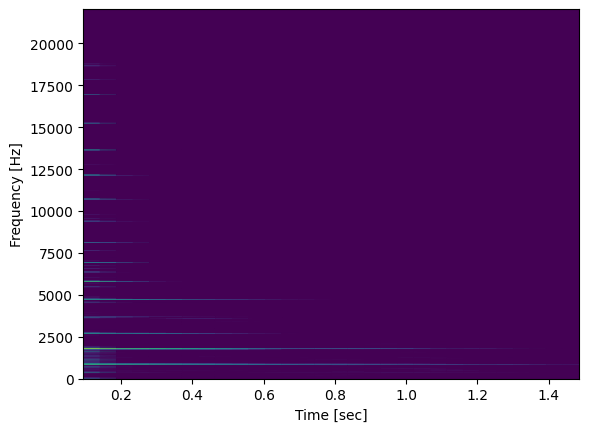

In [3]:
from scipy.signal import spectrogram

# Mostrem l'espectograma del senyal de referència
window_length = 8192
ff, tt, S = spectrogram(reference, fs=fs, nperseg=window_length, noverlap=window_length/2)
plot_spectrogram(ff, tt, S)

We can plot the spectrum (one slice of the spectrogram) of the signal at an specific time using the `plot_spectrum_at` function. For instance, we can see the spectrum of the signal at the 0.5 seconds:

In [4]:
# Espectograma en un temps concret (t=0.5 s)
plot_spectrum_at(ff, tt, S, 0.5)

1.1. Calculate and plot the spectrogram of your reference signal. Use `plt.ylim` to select the limits of the y axis in order to zoom in the frequency region of interest. For instance if you want to see the region between 0 and 4000 Hz, you can call `plt.ylim([0, 4000])` after the `plot_spectrogram` function.


(0.0, 10000.0)

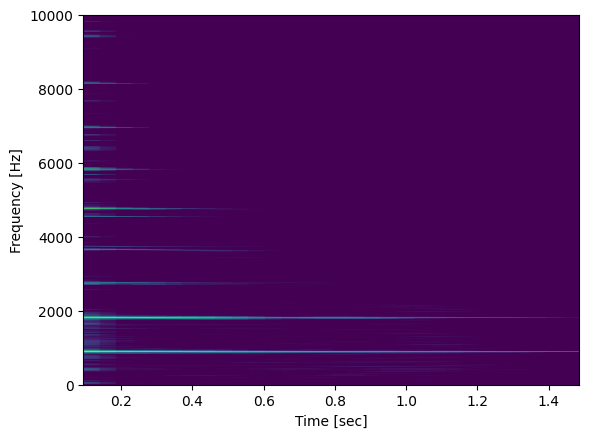

In [5]:
# Reduïm el limit superior de la freqüència
plot_spectrogram(ff, tt, S)
plt.ylim([0, 10000]) # Fins a f=10000 Hz

1.2. Select a time where almost all harmonics are present and plot the spectrum at that time.

In [6]:
# Mirant l'espectograma de dalt, seleccionem t=0.2 per observar bé els harmònics
plot_spectrum_at(ff, tt, S, 0.2)

1.3. Use the cursor for measuring the weights of the fundamental frequency and some harmonics (6-10)

In [7]:
frequencies = [915, 1841, 2751, 3677, 4570, 5566, 6390] # Apuntem les freqüències aproximades dels 7 primers harmònics
Ak = [1, 0.6, 0.06, 0.03, 0.03, 0.007, 0.003]  # Mesurem el pès de cada un dels harmònics apuntats

**2. Synthesis**:

Let's define a function to synthetize an harmonic singal which receives the fundamental frequency ($f_0$) and the weights ($A_k$) of each harmonic and the time vector ($t$). This is similar to what you did in Lab 3- Ex3.2.


In [8]:
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

2.1. Use the `synthetize` function to generate a synthesis with the weights ($A_k$) found in 1.3 and the fundamental frequency and phases found in previous labs. Plot both the reference and the synthetize signal. Listen to the synthetize signal.

In [9]:
# Paràmetres del senyal sintetitzat
f0 = 915.16                     # freqüència fonamental (ara més exacta gràcies al espectre)
phi = -np.pi / 2                # fase inicial
A_ref = 0.13                    # amplitud de referència
duration = 2.0                  # duració del so sintetitzat
t = np.linspace(0, duration, int(fs * duration))    # vector de temps

# Amplituds relatives mesurades (fins al 7è harmònic)
Ak = [1, 0.6, 0.06, 0.03, 0.03, 0.007, 0.003]

# Generem el senyal sintetitzat
synth = synthesize(f0, phi, Ak, t)

# Apliquem un atac ràpid al senyal i una decadència exponencial a l'amplitud per simular millor el so real
attack = np.minimum(t * 50, 1)         # atac ràpid
decay = np.exp(-11 * t)                # decadència exponencial
envelope = attack * decay
synth *= decay

# Afegim soroll suau per simular ressonància
noise = 0.005 * np.random.randn(len(t))
noise_decay = np.exp(-8 * t)   
noise *= noise_decay
synth += noise

# Normalització del senyal
synth = A_ref * synth / np.max(np.abs(synth))

# Comparem el senyal de referència amb el sintetitzat
plot_signals([reference[:len(synth)], synth], fs, t_start=0, t_end=2,
             name=['Referència', 'Senyal sintetitzat'])

2.2. Calculate the spectrogram of the synthesized signal `S_synt`; and compare the spectrums of both signals at the same time using `plot_spectrum_at(ff, tt, [S_ref, S_synt], time)`, where `S_ref`is spectrogram of the reference signal.

**Note:** use the same window length to calculate both spectrograms.

In [10]:
# Paràmetres de l’espectrograma
window_length = 8192  # mateix tamany de finestra per tots dos senyals

# Calculem l’espectrograma del senyal de referència
ff, tt, S_ref = spectrogram(reference, fs=fs, nperseg=window_length, noverlap=window_length / 2)

# Calculem l’espectrograma del senyal sintetitzat
ff, tt, S_synt = spectrogram(synth, fs=fs, nperseg=window_length, noverlap=window_length / 2)

# Comparem els dos espectres en un instant concret (t=0.2)
plot_spectrum_at(ff, tt, [S_ref, S_synt], 0.2)

# Senyal de referència --> color blau
# Senyal sintetitzat --> color taronja


2.3. Compare the spectrograms of the two signals. What are the main differences?

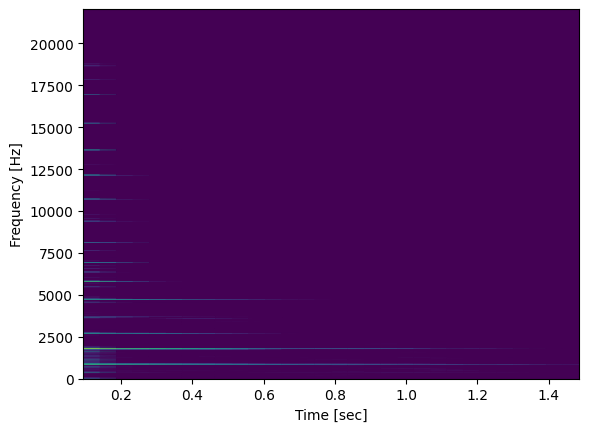

In [11]:
# Mostrem un altre cop l'espectograma del senyal de referència per comparar
window_length = 8192
ff, tt, S = spectrogram(reference, fs=fs, nperseg=window_length, noverlap=window_length/2)
plot_spectrogram(ff, tt, S)

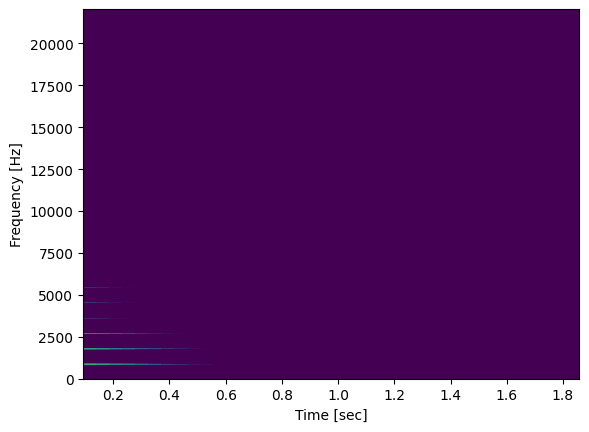

In [12]:
# Mostrem l'espectograma del senyal sintetitzat per comparar
window_length = 8192
ff, tt, S = spectrogram(synth, fs=fs, nperseg=window_length, noverlap=window_length/2)
plot_spectrogram(ff, tt, S)

L’espectrograma del senyal de referència mostra més harmònics, més soroll i més activitat en freqüències altes. El del senyal sintetitzat és més net i simple: té els harmònics principals però poca energia fora d’aquests. Això passa perquè el so real té ressonàncies i variacions naturals que no hem modelat.

2.4. Listen to the two audios (reference and synthesized). What are the main differences?

In [13]:
# Escoltem l'audio sintetitzat
Audio(synth,rate=fs)


In [14]:
# Guardem el so sintetitzat
save_audio("audio/synthetizised_signal.wav", synth, fs)

In [15]:
# Escoltem el so referència per comparar
Audio(reference, rate=fs)

El senyal de referència sona més natural i complex, amb més ressonàncies. El sintetitzat és més simple i regular, amb un so més pur però menys realista. Això es deu a que el so real prové d’un sistema físic amb vibracions irregulars que no hem modelat del tot.